In [1]:
!pip install streamlit joblib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 91.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import joblib
import json
import os
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

SEED = 42

# Load Dataset

In [3]:
df = pd.read_csv("/content/digital_printing_job_enhanced.csv")

print("Dataset shape:", df.shape)
display(df.head())
print(df.info())

Dataset shape: (23378, 17)


,Job_Type,Quantity,Color_Type (BW / Full Color),Material_Type,Order_Request_Date,Requested_Deadline_Date,Current_Queued_Jobs_Count,Active_Machines_Count,Total_Machines_Count,Available_Staff_Count,Total_Staff_Count,Priority,Assigned_Date,Estimated_End_Date,Assigned_Machine_Workload (%),Assigned_Operator_Workload (%),Delay_Risk_Level
0,Business Cards,NaN,BW,Canvas,2024-08-08,2024-08-15,116.0,4,6,9,11,Urgent,2024-08-09,2024-08-11,100.0,100.0,High
1,Brochures,436.0,Full Color,Vinyl,2018-07-18,2018-07-23,159.0,7,8,10,11,Urgent,2018-07-19,2018-07-30,100.0,100.0,High
2,Business Cards,402.0,BW,Glossy Paper,2017-12-31,2018-01-03,132.0,5,6,10,12,Normal,2018-01-01,2018-01-04,100.0,100.0,Low
3,Business Cards,896.0,BW,Cardboard,2023-06-20,2023-06-25,53.0,5,6,10,12,Normal,2023-06-21,2023-06-26,100.0,53.0,Low
4,NaN,NaN,BW,Glossy Paper,2020-12-09,2020-12-16,21.0,4,6,10,12,Normal,2020-12-10,2020-12-14,52.5,21.0,Low


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23378 entries, 0 to 23377
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Job_Type                        21265 non-null  object 
 1   Quantity                        10824 non-null  float64
 2   Color_Type (BW / Full Color)    21633 non-null  object 
 3   Material_Type                   21532 non-null  object 
 4   Order_Request_Date              23378 non-null  object 
 5   Requested_Deadline_Date         23378 non-null  object 
 6   Current_Queued_Jobs_Count       21402 non-null  float64
 7   Active_Machines_Count           23378 non-null  int64  
 8   Total_Machines_Count            23378 non-null  int64  
 9   Available_Staff_Count           23378 non-null  int64  
 10  Total_Staff_Count               23378 non-null  int64  
 11  Priority                        23378 non-null  object 
 12  Assigned_Date                   

# Check Missing Values and Target

In [4]:
print("Missing values:")
print(df.isnull().sum())

print("\nTarget value count:")
print(df["Delay_Risk_Level"].value_counts(dropna=False))

Missing values:
Job_Type                           2113
Quantity                          12554
Color_Type (BW / Full Color)       1745
Material_Type                      1846
Order_Request_Date                    0
Requested_Deadline_Date               0
Current_Queued_Jobs_Count          1976
Active_Machines_Count                 0
Total_Machines_Count                  0
Available_Staff_Count                 0
Total_Staff_Count                     0
Priority                              0
Assigned_Date                         0
Estimated_End_Date                    0
Assigned_Machine_Workload (%)      1976
Assigned_Operator_Workload (%)     1976
Delay_Risk_Level                   1877
dtype: int64

Target value count:
Delay_Risk_Level
Medium    9664
Low       6281
High      5556
NaN       1877
Name: count, dtype: int64


# Clean Dataset

In [5]:
TARGET = "Delay_Risk_Level"

df = df.dropna(subset=[TARGET]).copy()

print("After removing missing target rows:", df.shape)
print(df[TARGET].value_counts())

After removing missing target rows: (21501, 17)
Delay_Risk_Level
Medium    9664
Low       6281
High      5556
Name: count, dtype: int64


# Feature Engineering Class

In [6]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        date_cols = [
            "Order_Request_Date",
            "Requested_Deadline_Date",
            "Assigned_Date",
            "Estimated_End_Date"
        ]

        for col in date_cols:
            X[col] = pd.to_datetime(X[col], errors="coerce")

        X["days_to_deadline"] = (X["Requested_Deadline_Date"] - X["Order_Request_Date"]).dt.days
        X["days_to_assign"] = (X["Assigned_Date"] - X["Order_Request_Date"]).dt.days
        X["production_days"] = (X["Estimated_End_Date"] - X["Assigned_Date"]).dt.days
        X["deadline_buffer"] = (X["Requested_Deadline_Date"] - X["Estimated_End_Date"]).dt.days

        X["order_month"] = X["Order_Request_Date"].dt.month
        X["order_dayofweek"] = X["Order_Request_Date"].dt.dayofweek
        X["is_weekend_order"] = (X["order_dayofweek"] >= 5).astype(int)

        X["machine_util_ratio"] = X["Active_Machines_Count"] / X["Total_Machines_Count"].replace(0, np.nan)
        X["staff_util_ratio"] = (
            X["Total_Staff_Count"] - X["Available_Staff_Count"]
        ) / X["Total_Staff_Count"].replace(0, np.nan)

        X["queue_per_machine"] = X["Current_Queued_Jobs_Count"] / X["Active_Machines_Count"].replace(0, np.nan)
        X["queue_per_staff"] = X["Current_Queued_Jobs_Count"] / X["Available_Staff_Count"].replace(0, np.nan)

        X["avg_workload"] = (
            X["Assigned_Machine_Workload (%)"] + X["Assigned_Operator_Workload (%)"]
        ) / 2

        X["high_workload_flag"] = (X["avg_workload"] >= 80).astype(int)
        X["tight_deadline_flag"] = (X["days_to_deadline"] <= 3).astype(int)
        X["is_urgent"] = (X["Priority"] == "Urgent").astype(int)
        X["log_quantity"] = np.log1p(X["Quantity"])

        X = X.drop(columns=date_cols, errors="ignore")

        return X

# Split Data

In [7]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (17200, 16)
Test shape: (4301, 16)


# Preprocessing

In [8]:
categorical_features = [
    "Job_Type",
    "Color_Type (BW / Full Color)",
    "Material_Type",
    "Priority"
]

numeric_features = [
    "Quantity",
    "Current_Queued_Jobs_Count",
    "Active_Machines_Count",
    "Total_Machines_Count",
    "Available_Staff_Count",
    "Total_Staff_Count",
    "Assigned_Machine_Workload (%)",
    "Assigned_Operator_Workload (%)",
    "days_to_deadline",
    "days_to_assign",
    "production_days",
    "deadline_buffer",
    "order_month",
    "order_dayofweek",
    "is_weekend_order",
    "machine_util_ratio",
    "staff_util_ratio",
    "queue_per_machine",
    "queue_per_staff",
    "avg_workload",
    "high_workload_flag",
    "tight_deadline_flag",
    "is_urgent",
    "log_quantity"
]

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", onehot)
        ]), categorical_features)
    ]
)

# Train 3 Models

# Logistic Regression Model

In [9]:
logistic_model = Pipeline([
    ("feature_engineering", FeatureEngineer()),
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=SEED
    ))
])

logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr, average="weighted")

print("Logistic Regression Evaluation")
print("Accuracy:", lr_accuracy)
print("Weighted F1 Score:", lr_f1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Evaluation
Accuracy: 0.6514764008370146
Weighted F1 Score: 0.6572229978957516

Classification Report:
              precision    recall  f1-score   support

        High       0.38      0.57      0.46      1111
         Low       1.00      1.00      1.00      1257
      Medium       0.66      0.47      0.55      1933

    accuracy                           0.65      4301
   macro avg       0.68      0.68      0.67      4301
weighted avg       0.69      0.65      0.66      4301



# Random Forest Model

In [10]:
random_forest_model = Pipeline([
    ("feature_engineering", FeatureEngineer()),
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=SEED
    ))
])

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf, average="weighted")

print("Random Forest Evaluation")
print("Accuracy:", rf_accuracy)
print("Weighted F1 Score:", rf_f1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Evaluation
Accuracy: 0.8235294117647058
Weighted F1 Score: 0.8018716587565499

Classification Report:
              precision    recall  f1-score   support

        High       0.85      0.38      0.53      1111
         Low       1.00      1.00      1.00      1257
      Medium       0.73      0.96      0.83      1933

    accuracy                           0.82      4301
   macro avg       0.86      0.78      0.79      4301
weighted avg       0.84      0.82      0.80      4301



# XGBoost Model

In [11]:
!pip install xgboost -q
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

xgb_pipeline = Pipeline([
    ("feature_engineering", FeatureEngineer()),
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=SEED,
        tree_method="hist"
    ))
])

param_grid = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__max_depth": [3, 4, 5, 6, 7],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__gamma": [0, 0.1, 0.2, 0.5],
    "model__reg_alpha": [0, 0.01, 0.1, 1],
    "model__reg_lambda": [1, 1.5, 2, 3]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_grid,
    n_iter=30,
    scoring="f1_weighted",
    cv=3,
    verbose=2,
    random_state=SEED,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train_encoded)

best_xgboost_model = xgb_search.best_estimator_

y_pred_xgb_encoded = best_xgboost_model.predict(X_test)
y_pred_xgb = label_encoder.inverse_transform(y_pred_xgb_encoded)

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb, average="weighted")

print("Best XGBoost Parameters:")
print(xgb_search.best_params_)

print("\nTuned XGBoost Evaluation")
print("Accuracy:", xgb_accuracy)
print("Weighted F1 Score:", xgb_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best XGBoost Parameters:
{'model__subsample': 0.8, 'model__reg_lambda': 3, 'model__reg_alpha': 1, 'model__n_estimators': 500, 'model__max_depth': 7, 'model__learning_rate': 0.1, 'model__gamma': 0.2, 'model__colsample_bytree': 0.8}

Tuned XGBoost Evaluation
Accuracy: 0.8621250871890258
Weighted F1 Score: 0.8561450979125667

Classification Report:
              precision    recall  f1-score   support

        High       0.82      0.59      0.69      1111
         Low       1.00      1.00      1.00      1257
      Medium       0.80      0.93      0.86      1933

    accuracy                           0.86      4301
   macro avg       0.87      0.84      0.85      4301
weighted avg       0.86      0.86      0.86      4301



# Confusion Matrix

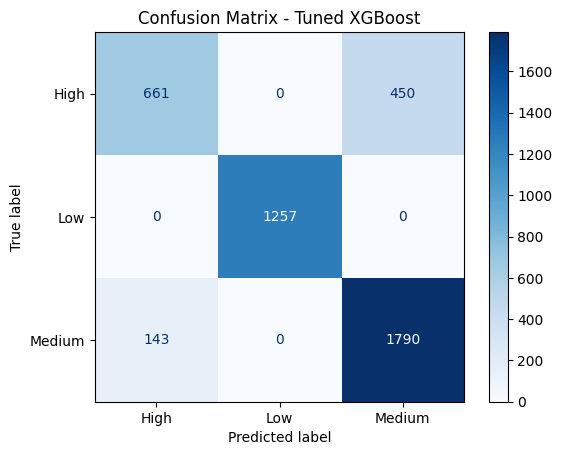

In [12]:
cm = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Tuned XGBoost")
plt.show()

# Model Comparison Table

In [13]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Weighted F1 Score": [
        lr_f1,
        rf_f1,
        xgb_f1
    ]
})

model_results = model_results.sort_values(
    by="Weighted F1 Score",
    ascending=False
)

display(model_results)

,Model,Accuracy,Weighted F1 Score
2,XGBoost,0.862125,0.856145
1,Random Forest,0.823529,0.801872
0,Logistic Regression,0.651476,0.657223


# Save Tuned XGBoost Model

In [14]:
import os
import joblib
import json

os.makedirs("saved_model", exist_ok=True)

joblib.dump(best_xgboost_model, "saved_model/best_xgboost_delay_model.pkl")
joblib.dump(label_encoder, "saved_model/label_encoder.pkl")

metadata = {
    "model_name": "Tuned XGBoost",
    "accuracy": xgb_accuracy,
    "weighted_f1_score": xgb_f1,
    "classes": list(label_encoder.classes_),
    "best_parameters": xgb_search.best_params_,
    "input_columns": list(X.columns)
}

with open("saved_model/xgboost_model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("Tuned XGBoost model saved successfully!")

Tuned XGBoost model saved successfully!


# Test Saved Model

In [15]:
loaded_model = joblib.load("saved_model/best_xgboost_delay_model.pkl")

sample = pd.DataFrame([{
    "Job_Type": "Brochures",
    "Quantity": 500,
    "Color_Type (BW / Full Color)": "Full Color",
    "Material_Type": "Glossy Paper",
    "Order_Request_Date": "2025-04-01",
    "Requested_Deadline_Date": "2025-04-04",
    "Current_Queued_Jobs_Count": 80,
    "Active_Machines_Count": 4,
    "Total_Machines_Count": 6,
    "Available_Staff_Count": 3,
    "Total_Staff_Count": 8,
    "Priority": "Urgent",
    "Assigned_Date": "2025-04-02",
    "Estimated_End_Date": "2025-04-05",
    "Assigned_Machine_Workload (%)": 85,
    "Assigned_Operator_Workload (%)": 90
}])

prediction = loaded_model.predict(sample)
probability = loaded_model.predict_proba(sample)

print("Predicted Delay Risk:", prediction[0])
print("Probability:", probability)

Predicted Delay Risk: 2
Probability: [[4.1002190e-01 2.0626718e-04 5.8977187e-01]]
